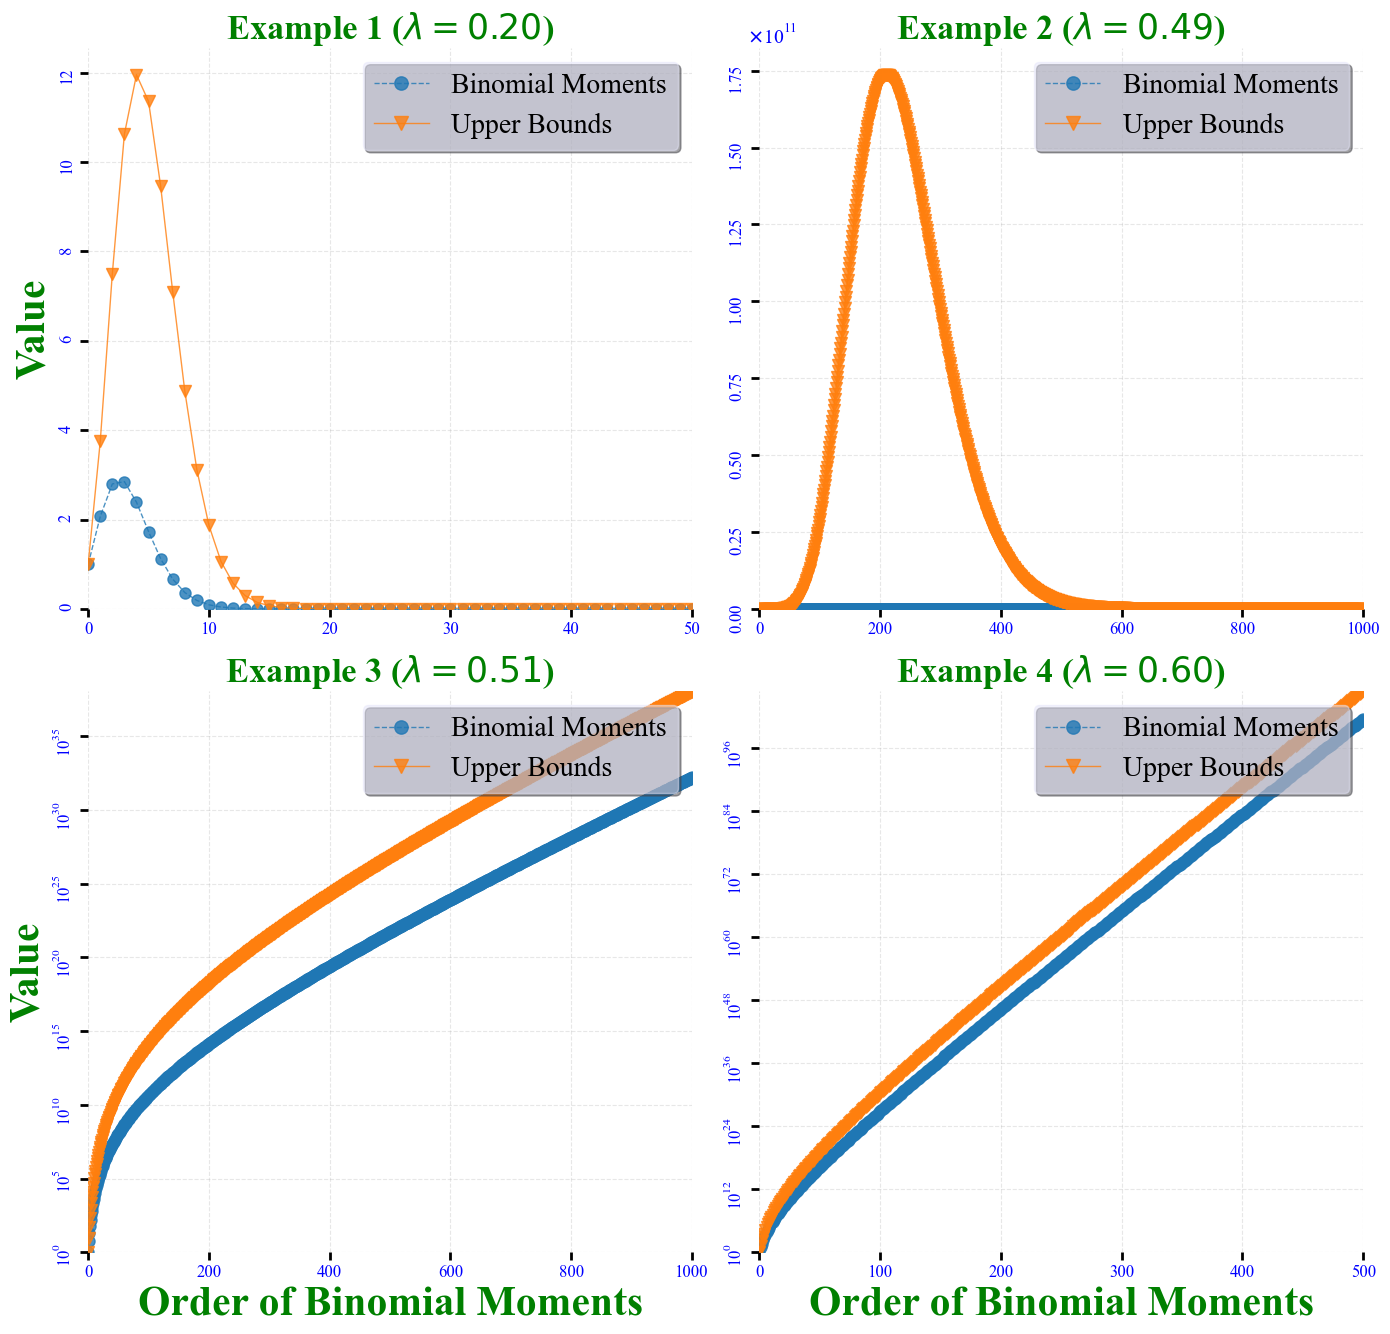

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

plt.rcParams['axes.linewidth'] = 2

data_dir = Path('Binomial_Bound')
x_max_list = [51, 1001, 1001, 501]
lam = [0.2, 0.49, 0.51, 0.6]

fig, axes = plt.subplots(2, 2, figsize=(14, 14), dpi=100)
axes = axes.flatten()

for i in range(1, 5):
    ax = axes[i - 1]
    x_max = x_max_list[i - 1]

    real_path = data_dir / f'BM_real{i}.npy'
    bound_path = data_dir / f'BM_bound{i}.npy'

    BM_real = np.load(real_path, allow_pickle=True).flatten()
    BM_bound = np.load(bound_path, allow_pickle=True).flatten()

    BM_real = np.asarray(BM_real, dtype=float)
    BM_bound = np.asarray(BM_bound, dtype=float)

    n = min(x_max, len(BM_real), len(BM_bound))

    if n == 0:
        raise ValueError(f'No valid data points were found for Example {i}.')

    x = np.arange(n)
    real_plot = BM_real[:n]
    bound_plot = BM_bound[:n]

    ax.plot(
        x,
        real_plot,
        linestyle='--',
        marker='o',
        markersize=8,
        linewidth=1,
        alpha=0.8,
        label='Binomial Moments'
    )

    ax.plot(
        x,
        bound_plot,
        linestyle='-',
        marker='v',
        markersize=8,
        linewidth=1,
        alpha=0.8,
        label='Upper Bounds'
    )

    ax.set_xlim(0, n - 1)

    if i <= 2:
        finite_values = np.concatenate([
            real_plot[np.isfinite(real_plot)],
            bound_plot[np.isfinite(bound_plot)]
        ])

        if finite_values.size > 0:
            y_max = np.max(finite_values)
            ax.set_ylim(0, 1.05 * y_max if y_max > 0 else 1)
        else:
            ax.set_ylim(0, 1)
    else:
        ax.set_yscale('log')

        positive_values = np.concatenate([
            real_plot[np.isfinite(real_plot) & (real_plot > 0)],
            bound_plot[np.isfinite(bound_plot) & (bound_plot > 0)]
        ])

        if positive_values.size > 0:
            y_min = np.min(positive_values)
            y_max = np.max(positive_values)

            if y_min == y_max:
                ax.set_ylim(0.9 * y_min, 1.1 * y_max)
            else:
                ax.set_ylim(y_min, 1.05 * y_max)
        else:
            ax.set_ylim(1e-12, 1)

    ax.set_title(
        rf'Example {i} ($\lambda={lam[i - 1]:.2f}$)',
        fontname='Times New Roman',
        fontsize=25,
        fontweight='bold',
        color='green'
    )

    row = (i - 1) // 2
    col = (i - 1) % 2

    if col == 0:
        ax.set_ylabel(
            'Value',
            fontsize=30,
            fontweight='bold',
            fontname='Times New Roman',
            color='green'
        )

    if row == 1:
        ax.set_xlabel(
            'Order of Binomial Moments',
            fontsize=30,
            fontweight='bold',
            fontname='Times New Roman',
            color='green'
        )

    ax.tick_params(
        direction='out',
        width=2,
        length=6,
        labelsize=12
    )

    if i == 2:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)

        offset_text = ax.yaxis.get_offset_text()
        offset_text.set_fontname('Times New Roman')
        offset_text.set_fontsize(14)
        offset_text.set_color('blue')
        offset_text.set_x(-0.02)
        offset_text.set_y(1.01)

    for label in ax.get_xticklabels():
        label.set_fontname('Times New Roman')
        label.set_color('blue')

    for label in ax.get_yticklabels():
        label.set_fontname('Times New Roman')
        label.set_color('blue')
        label.set_rotation(90)

    ax.grid(True, linestyle='--', alpha=0.3)

    legend = ax.legend(
        loc='upper right',
        frameon=True,
        shadow=True,
        markerscale=1.2,
        fancybox=True,
        prop={
            'family': 'Times New Roman',
            'size': 20
        }
    )

    legend.get_frame().set_color('#E6E6FA')
    legend.get_frame().set_alpha(0.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

# fig.suptitle(
#     'Binomial Moments and Upper Bounds',
#     fontname='Times New Roman',
#     fontsize=30,
#     fontweight='bold',
#     color='green'
# )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    'FigS2.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=600
)
plt.show()
